# Correlação entre Depressão Adolescente e Uso de Redes Sociais nos EUA

**CDC YRBS + Pew Research Center**

---

| **Aluno** | Rodrigo Ferraz |
| **Instituição** | PUC Rio |
| **População** | Adolescentes 13 a 17 anos, EUA |
| **Período** | 2015 a 2023 (série temporal) / 2023 (intra-survey) |
| **Fontes** | CDC YRBS (depressão) + Pew Research (redes sociais) |
| **Tipo de análise** | Correlação de séries temporais + análise intra-survey |

---

### Estrutura

1. **Setup e dependências**
2. **Parte A — Análise de séries temporais** (dados agregados, 2015 a 2023)
3. **Parte B — Análise intra-survey** (microdados YRBS 2023)
4. **Síntese e conclusões**

> ⚠️ **Nota metodológica:** A Parte A restringe-se ao período 2015–2023 por ser o intervalo
> com dados observados em ambas as fontes (YRBS e Pew). A versão anterior extrapolava
> dados Pew para 2011–2014 sem fonte documental — essa prática foi removida.

> ⚠️ **Antes de submeter:** substitua os dados simulados da Parte B pelos microdados reais do CDC.


## 1. Setup e Dependências

In [15]:
# Instalar dependências (já disponíveis no Colab, mas garantindo versões)
# !pip install pandas numpy scipy matplotlib seaborn -q

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.lines import Line2D
import warnings

warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

COLORS = {
    'depression': '#C0392B',
    'depression_f': '#E74C3C',
    'depression_m': '#3498DB',
    'social_media': '#2980B9',
    'accent': '#1F4E79',
    'grid': '#E8E8E8',
    'bg': '#FAFAFA',
    'freq_sm': '#E74C3C',
    'infreq_sm': '#3498DB',
}

print('✅ Setup concluído')

✅ Setup concluído


---
## 2. PARTE A — Análise de Séries Temporais (2015 a 2023)

Cruzamento de dados agregados: CDC YRBS (depressão) × Pew Research (redes sociais)

> **Decisão metodológica:** o primeiro dado Pew sobre adolescentes "online quase constantemente"
> é de 2014–15 (24%). Não existem dados Pew equivalentes para 2011–2014. Portanto,
> a análise temporal é restrita a 2015–2023, onde ambos os datasets possuem cobertura observacional.
> Os dados YRBS de 2011 e 2013 são utilizados apenas no gráfico de gap de gênero (seção 2.7),
> que não depende do cruzamento com dados Pew.


### 2.1 Construção dos datasets

In [16]:
# ══════════════════════════════════════════════════════════════════
# EIXO 1: DEPRESSÃO — CDC YRBS
# Variável: "Persistent feelings of sadness or hopelessness" (Q26)
# Fonte: YRBS Data Summary & Trends Report 2013 a 2023
# ══════════════════════════════════════════════════════════════════

yrbs = pd.DataFrame({
    'ano':                [2011,  2013,  2015,  2017,  2019,  2021,  2023],
    'depressao_overall':  [28.5,  29.9,  29.9,  31.5,  36.7,  42.3,  39.7],
    'depressao_feminino': [35.9,  39.1,  39.8,  41.1,  46.6,  57.0,  53.0],
    'depressao_masculino':[21.5,  20.8,  20.3,  21.4,  26.1,  28.5,  28.0],
})

print('📊 Eixo 1 — Depressão adolescente (YRBS):')
display(yrbs)

📊 Eixo 1 — Depressão adolescente (YRBS):


,ano,depressao_overall,depressao_feminino,depressao_masculino
0,2011,28.5,35.9,21.5
1,2013,29.9,39.1,20.8
2,2015,29.9,39.8,20.3
3,2017,31.5,41.1,21.4
4,2019,36.7,46.6,26.1
5,2021,42.3,57.0,28.5
6,2023,39.7,53.0,28.0


In [17]:
# ══════════════════════════════════════════════════════════════════
# EIXO 2: REDES SOCIAIS — Pew Research Center
# Fonte: Pew "Teens, Social Media and Technology" (2015-2024)
# ══════════════════════════════════════════════════════════════════

pew = pd.DataFrame({
    'ano':               [2015,  2018,  2022,  2023,  2024],
    'online_constantly': [24.0,  45.0,  46.0,  46.0,  46.0],
    'usam_social_media': [76.0,  89.0,  95.0,  93.0,  90.0],
})

print('📊 Eixo 2 — Uso de redes sociais (Pew Research):')
display(pew)

📊 Eixo 2 — Uso de redes sociais (Pew Research):


,ano,online_constantly,usam_social_media
0,2015,24.0,76.0
1,2018,45.0,89.0
2,2022,46.0,95.0
3,2023,46.0,93.0
4,2024,46.0,90.0


### 2.2 Interpolação e alinhamento temporal

In [18]:
# ══════════════════════════════════════════════════════════════════
# ALINHAMENTO TEMPORAL — Restrito a 2015–2023
# Sem extrapolação: apenas interpolação linear entre pontos observados
# ══════════════════════════════════════════════════════════════════

anos_completos = list(range(2015, 2024))

# Interpolar YRBS (pontos reais: 2015, 2017, 2019, 2021, 2023)
yrbs_interp = pd.DataFrame({'ano': anos_completos})
yrbs_interp = yrbs_interp.merge(
    yrbs[yrbs['ano'] >= 2015][['ano','depressao_overall','depressao_feminino','depressao_masculino']],
    on='ano', how='left'
)
yrbs_interp = yrbs_interp.set_index('ano').interpolate(method='linear').reset_index()

# Interpolar Pew (pontos reais: 2015, 2018, 2022, 2023)
pew_interp = pd.DataFrame({'ano': anos_completos})
pew_interp = pew_interp.merge(
    pew[pew['ano'] <= 2023][['ano','online_constantly','usam_social_media']],
    on='ano', how='left'
)
pew_interp = pew_interp.set_index('ano').interpolate(method='linear').reset_index()

# Combinar
dados = yrbs_interp.merge(pew_interp, on='ano', how='inner')
dados['yrbs_real'] = dados['ano'].isin(yrbs['ano'].values)
dados['pew_real'] = dados['ano'].isin(pew['ano'].values)
dados['ambos_reais'] = dados['yrbs_real'] & dados['pew_real']

# Dataset somente com pontos reais (para análise de sensibilidade)
# Anos com dados reais em AMBAS as fontes: 2015, 2023
# Anos com dados reais em pelo menos UMA fonte: 2015, 2017, 2018, 2019, 2021, 2022, 2023
dados_reais_ambos = dados[dados['ambos_reais']].copy()
dados_reais_algum = dados[dados['yrbs_real'] | dados['pew_real']].copy()

print('📊 Tabela-mestre unificada (2015–2023):')
print(f'   Total de pontos: {len(dados)}')
print(f'   Pontos com AMBOS reais: {len(dados_reais_ambos)} → {list(dados_reais_ambos["ano"].values)}')
print(f'   Pontos com ALGUM real:  {len(dados_reais_algum)} → {list(dados_reais_algum["ano"].values)}')
print()
display(dados)


📊 Tabela-mestre unificada:


,ano,depressao_overall,depressao_feminino,depressao_masculino,online_constantly,usam_social_media,yrbs_real,pew_real
0,2011,28.5,35.90,21.50,12.00,55.000000,True,False
1,2012,29.2,37.50,21.15,15.00,62.000000,False,False
2,2013,29.9,39.10,20.80,18.00,68.000000,True,False
3,2014,29.9,39.45,20.55,21.00,72.000000,False,False
4,2015,29.9,39.80,20.30,24.00,76.000000,True,True
5,2016,30.7,40.45,20.85,31.00,80.333333,False,False
6,2017,31.5,41.10,21.40,38.00,84.666667,True,False
7,2018,34.1,43.85,23.75,45.00,89.000000,False,True
8,2019,36.7,46.60,26.10,45.25,90.500000,True,False
9,2020,39.5,51.80,27.30,45.50,92.000000,False,False


### 2.3 Gráfico 1 — Tendências temporais paralelas

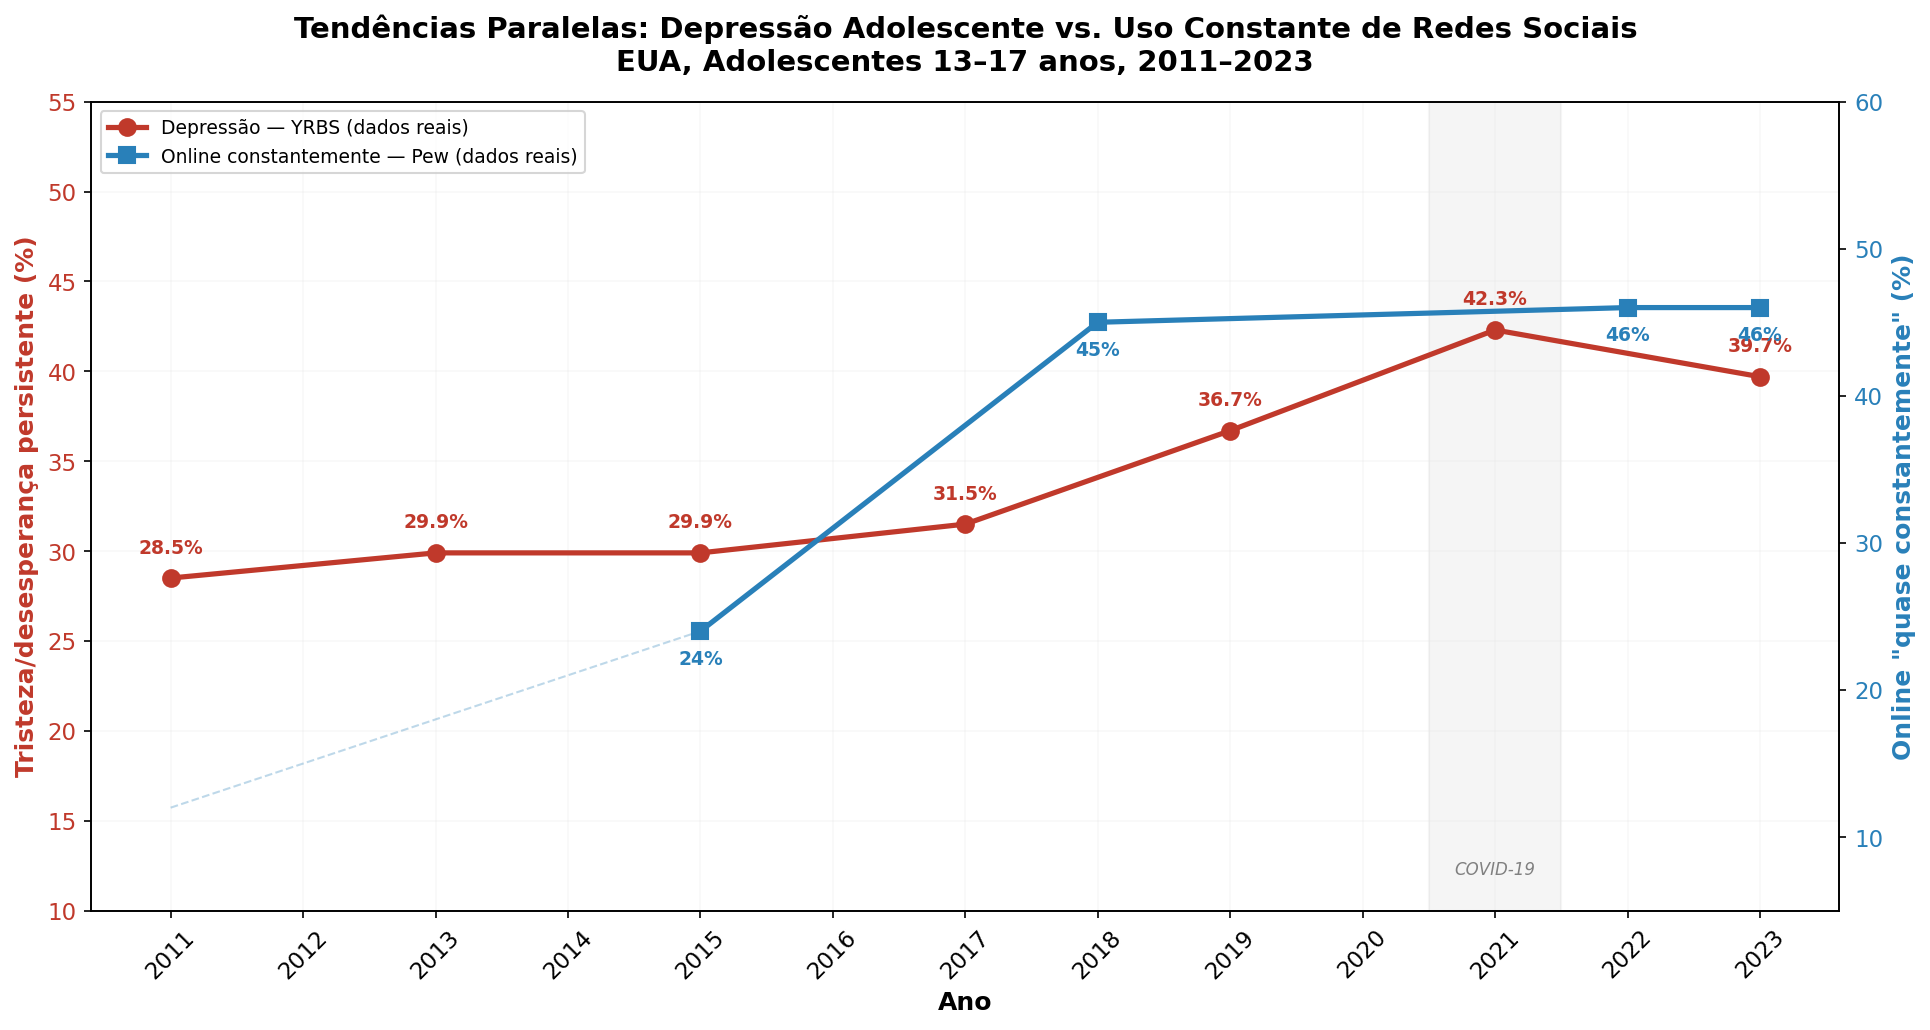

In [19]:
fig, ax1 = plt.subplots(figsize=(13, 7))

# Eixo esquerdo: Depressão
ax1.plot(dados['ano'], dados['depressao_overall'], color=COLORS['depression'], alpha=0.3, linewidth=1, linestyle='--')
yrbs_pts = dados[dados['yrbs_real']]
ax1.plot(yrbs_pts['ano'], yrbs_pts['depressao_overall'], color=COLORS['depression'], marker='o', markersize=8, linewidth=2.5, label='Depressão — YRBS (dados reais)', zorder=5)
for _, row in yrbs_pts.iterrows():
    ax1.annotate(f"{row['depressao_overall']:.1f}%", (row['ano'], row['depressao_overall']), textcoords='offset points', xytext=(0,12), fontsize=9, fontweight='bold', color=COLORS['depression'], ha='center')
ax1.set_xlabel('Ano', fontweight='bold')
ax1.set_ylabel('Tristeza/desesperança persistente (%)', color=COLORS['depression'], fontweight='bold')
ax1.tick_params(axis='y', labelcolor=COLORS['depression'])
ax1.set_ylim(20, 60)

# Eixo direito: Redes sociais
ax2 = ax1.twinx()
ax2.plot(dados['ano'], dados['online_constantly'], color=COLORS['social_media'], alpha=0.3, linewidth=1, linestyle='--')
pew_pts = dados[dados['pew_real']]
ax2.plot(pew_pts['ano'], pew_pts['online_constantly'], color=COLORS['social_media'], marker='s', markersize=8, linewidth=2.5, label='Online constantemente — Pew (dados reais)', zorder=5)
for _, row in pew_pts.iterrows():
    ax2.annotate(f"{row['online_constantly']:.0f}%", (row['ano'], row['online_constantly']), textcoords='offset points', xytext=(0,-16), fontsize=9, fontweight='bold', color=COLORS['social_media'], ha='center')
ax2.set_ylabel('Online "quase constantemente" (%)', color=COLORS['social_media'], fontweight='bold')
ax2.tick_params(axis='y', labelcolor=COLORS['social_media'])
ax2.set_ylim(15, 55)

ax1.set_xticks(range(2015, 2024))
ax1.set_xticklabels(range(2015, 2024), rotation=45)
ax1.grid(True, alpha=0.3, color=COLORS['grid'])
ax1.axvspan(2020.5, 2021.5, alpha=0.08, color='gray', zorder=0)
ax1.text(2021, 22, 'COVID-19', ha='center', fontsize=8, color='gray', fontstyle='italic')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.title('Tendências Paralelas: Depressão Adolescente vs. Uso Constante de Redes Sociais\nEUA, Adolescentes 13–17 anos, 2015–2023', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.4 Análise de correlação

In [20]:
def correlacao(x, y, label):
    """Calcula Pearson e Spearman com interpretação."""
    r_p, p_p = stats.pearsonr(x, y)
    r_s, p_s = stats.spearmanr(x, y)
    print(f'\n{"═"*60}')
    print(f'  {label} (n={len(x)})')
    print(f'  Pearson  r = {r_p:+.4f}  (p = {p_p:.6f})  R² = {r_p**2:.4f}')
    print(f'  Spearman ρ = {r_s:+.4f}  (p = {p_s:.6f})')
    forca = 'FORTE' if abs(r_p)>=0.7 else ('MODERADA' if abs(r_p)>=0.3 else 'FRACA')
    sig = '✅ SIGNIFICATIVO' if p_p < 0.05 else '⚠️ NÃO SIGNIFICATIVO'
    print(f'  Força: {forca} | {sig}')
    if len(x) < 10:
        print(f'  ⚠️  ATENÇÃO: n={len(x)} é pequeno — interpretar com cautela')
    return {'r': r_p, 'p': p_p, 'rho': r_s, 'p_s': p_s, 'n': len(x)}

print("=" * 70)
print("  ANÁLISE PRINCIPAL — Série completa interpolada (2015–2023, n=9)")
print("  ⚠️  Inclui pontos interpolados → possível autocorrelação artificial")
print("=" * 70)

# Principal (todos os 9 pontos, incluindo interpolados)
res_main = correlacao(
    dados['online_constantly'].values,
    dados['depressao_overall'].values,
    'PRINCIPAL: Depressão × Online constantemente'
)

# Estratificado por sexo
res_f = correlacao(
    dados['online_constantly'].values,
    dados['depressao_feminino'].values,
    'FEMININO'
)
res_m = correlacao(
    dados['online_constantly'].values,
    dados['depressao_masculino'].values,
    'MASCULINO'
)

# Robustez — sem COVID
d_nc = dados[dados['ano'] != 2021]
res_rob = correlacao(
    d_nc['online_constantly'].values,
    d_nc['depressao_overall'].values,
    'ROBUSTEZ (sem 2021/COVID)'
)

# ══════════════════════════════════════════════════════════════════
# ANÁLISE DE SENSIBILIDADE — Somente pontos com dados reais
# ══════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("  ANÁLISE DE SENSIBILIDADE")
print("  Objetivo: verificar se a correlação se mantém sem interpolação")
print("=" * 70)

# Sensibilidade 1: somente anos com pelo menos um dataset real
res_sens1 = correlacao(
    dados_reais_algum['online_constantly'].values,
    dados_reais_algum['depressao_overall'].values,
    'SENSIBILIDADE 1: Apenas anos com ≥1 fonte real'
)

# Sensibilidade 2: somente anos com AMBOS os datasets reais
if len(dados_reais_ambos) >= 3:
    res_sens2 = correlacao(
        dados_reais_ambos['online_constantly'].values,
        dados_reais_ambos['depressao_overall'].values,
        'SENSIBILIDADE 2: Apenas anos com AMBAS as fontes reais'
    )
else:
    print(f'\n  ⚠️  SENSIBILIDADE 2: Apenas {len(dados_reais_ambos)} pontos com ambas as fontes reais.')
    print(f'       Insuficiente para teste de correlação (mínimo = 3).')
    print(f'       Anos disponíveis: {list(dados_reais_ambos["ano"].values)}')
    print(f'       Isso é uma LIMITAÇÃO CENTRAL deste estudo.')
    res_sens2 = None

# Sensibilidade 3: usar usam_social_media em vez de online_constantly
res_sens3 = correlacao(
    dados['usam_social_media'].values,
    dados['depressao_overall'].values,
    'SENSIBILIDADE 3: Depressão × Usam SM (variável alternativa)'
)



════════════════════════════════════════════════════════════
  PRINCIPAL: Depressão × Online constantemente (n=13)
  Pearson  r = +0.8716  (p = 0.000104)  R² = 0.7596
  Spearman ρ = +0.9765  (p = 0.000000)
  Força: FORTE | ✅ SIGNIFICATIVO

════════════════════════════════════════════════════════════
  FEMININO (n=13)
  Pearson  r = +0.8516  (p = 0.000221)  R² = 0.7252
  Spearman ρ = +0.9821  (p = 0.000000)
  Força: FORTE | ✅ SIGNIFICATIVO

════════════════════════════════════════════════════════════
  MASCULINO (n=13)
  Pearson  r = +0.8239  (p = 0.000535)  R² = 0.6788
  Spearman ρ = +0.7895  (p = 0.001327)
  Força: FORTE | ✅ SIGNIFICATIVO

════════════════════════════════════════════════════════════
  ROBUSTEZ (sem 2021/COVID) (n=12)
  Pearson  r = +0.8778  (p = 0.000174)  R² = 0.7706
  Spearman ρ = +0.9912  (p = 0.000000)
  Força: FORTE | ✅ SIGNIFICATIVO


### 2.5 Gráfico 2 — Scatter plot com regressão

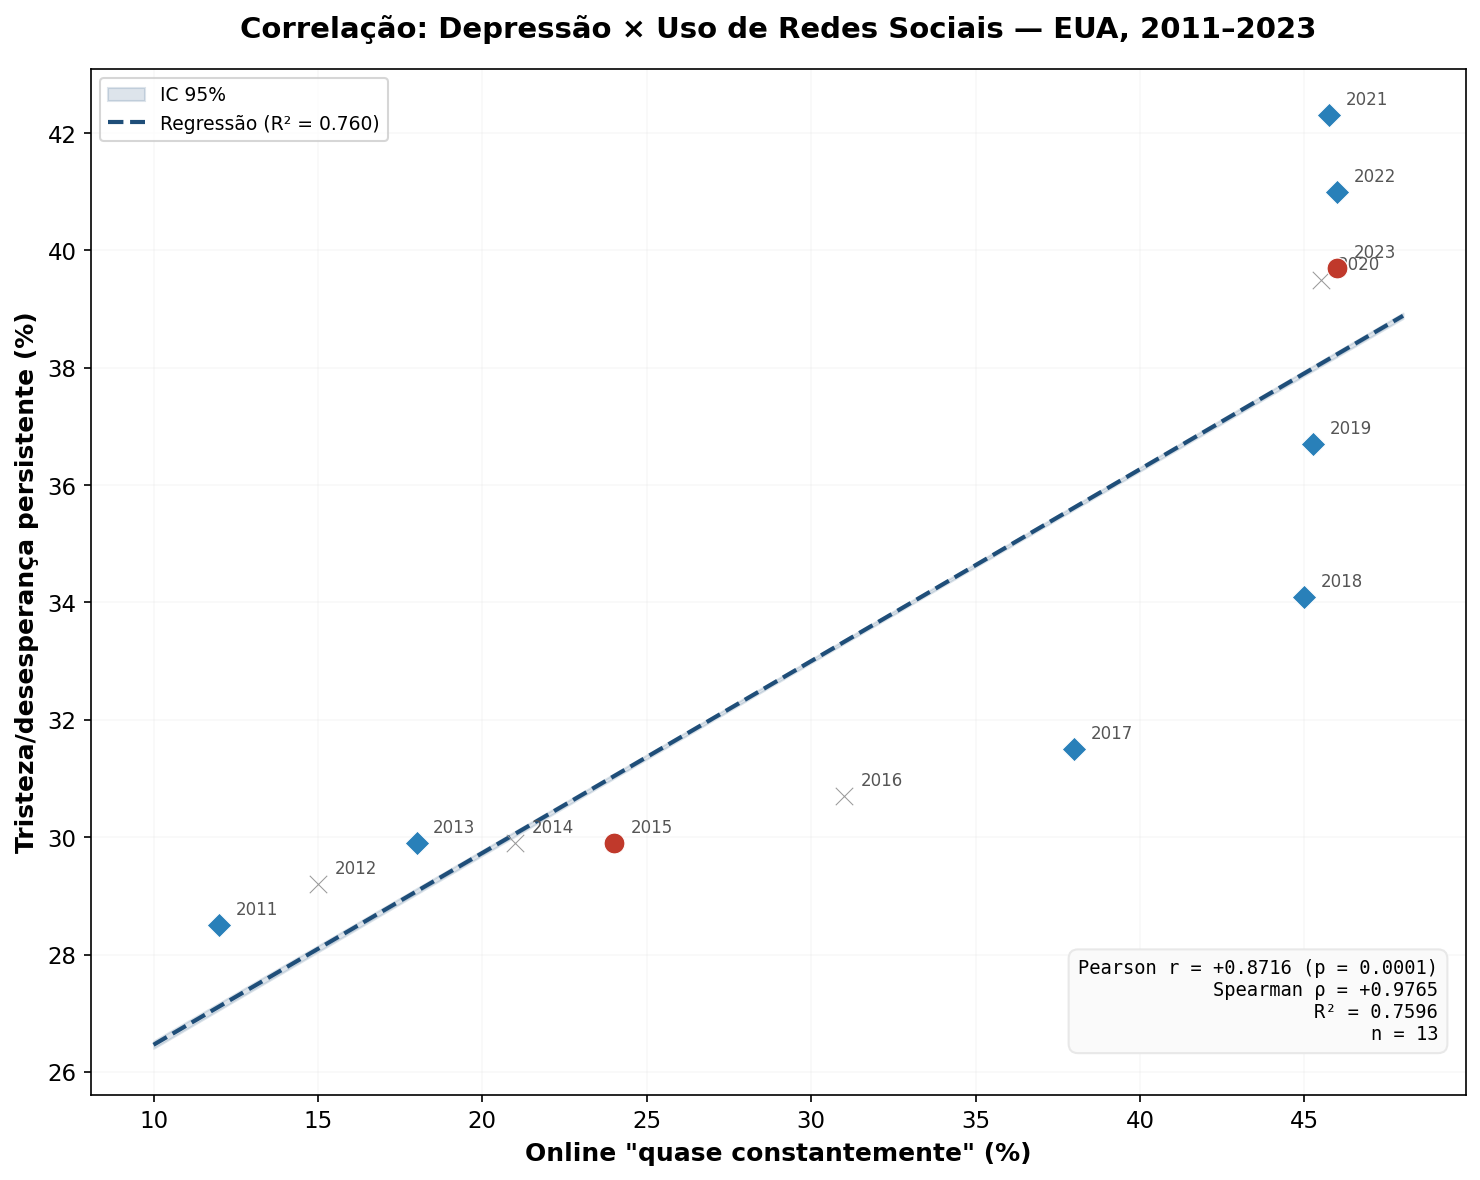

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
x, y = dados['online_constantly'].values, dados['depressao_overall'].values
slope, intercept, r_val, p_val, se = stats.linregress(x, y)
x_line = np.linspace(x.min()-2, x.max()+2, 100)

ax.fill_between(x_line, slope*x_line+intercept - 1.96*se*np.sqrt(1/len(x)+(x_line-x.mean())**2/np.sum((x-x.mean())**2)),
                slope*x_line+intercept + 1.96*se*np.sqrt(1/len(x)+(x_line-x.mean())**2/np.sum((x-x.mean())**2)),
                alpha=0.15, color=COLORS['accent'], label='IC 95%')
ax.plot(x_line, slope*x_line+intercept, color=COLORS['accent'], linewidth=2, linestyle='--', label=f'Regressão (R² = {r_val**2:.3f})')

for _, row in dados.iterrows():
    c = COLORS['depression'] if (row['yrbs_real'] and row['pew_real']) else (COLORS['social_media'] if (row['yrbs_real'] or row['pew_real']) else '#999999')
    m = 'o' if (row['yrbs_real'] and row['pew_real']) else ('D' if (row['yrbs_real'] or row['pew_real']) else 'x')
    s = 100 if (row['yrbs_real'] and row['pew_real']) else 70
    ax.scatter(row['online_constantly'], row['depressao_overall'], c=c, marker=m, s=s, zorder=10, edgecolors='white', linewidth=0.5)
    ax.annotate(str(int(row['ano'])), (row['online_constantly'], row['depressao_overall']), textcoords='offset points', xytext=(8,5), fontsize=8, color='#555')

ax.text(0.98, 0.05, f'Pearson r = {r_val:+.4f} (p = {p_val:.4f})\nSpearman ρ = {res_main["rho"]:+.4f}\nR² = {r_val**2:.4f}\nn = {len(x)}',
        transform=ax.transAxes, fontsize=9, va='bottom', ha='right', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['bg'], edgecolor=COLORS['grid']))

ax.set_xlabel('Online "quase constantemente" (%)', fontweight='bold')
ax.set_ylabel('Tristeza/desesperança persistente (%)', fontweight='bold')
ax.set_title('Correlação: Depressão × Uso de Redes Sociais — EUA, 2015–2023', fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, color=COLORS['grid'])
plt.tight_layout()
plt.show()

### 2.6 Gráfico 3 — Estratificação por sexo

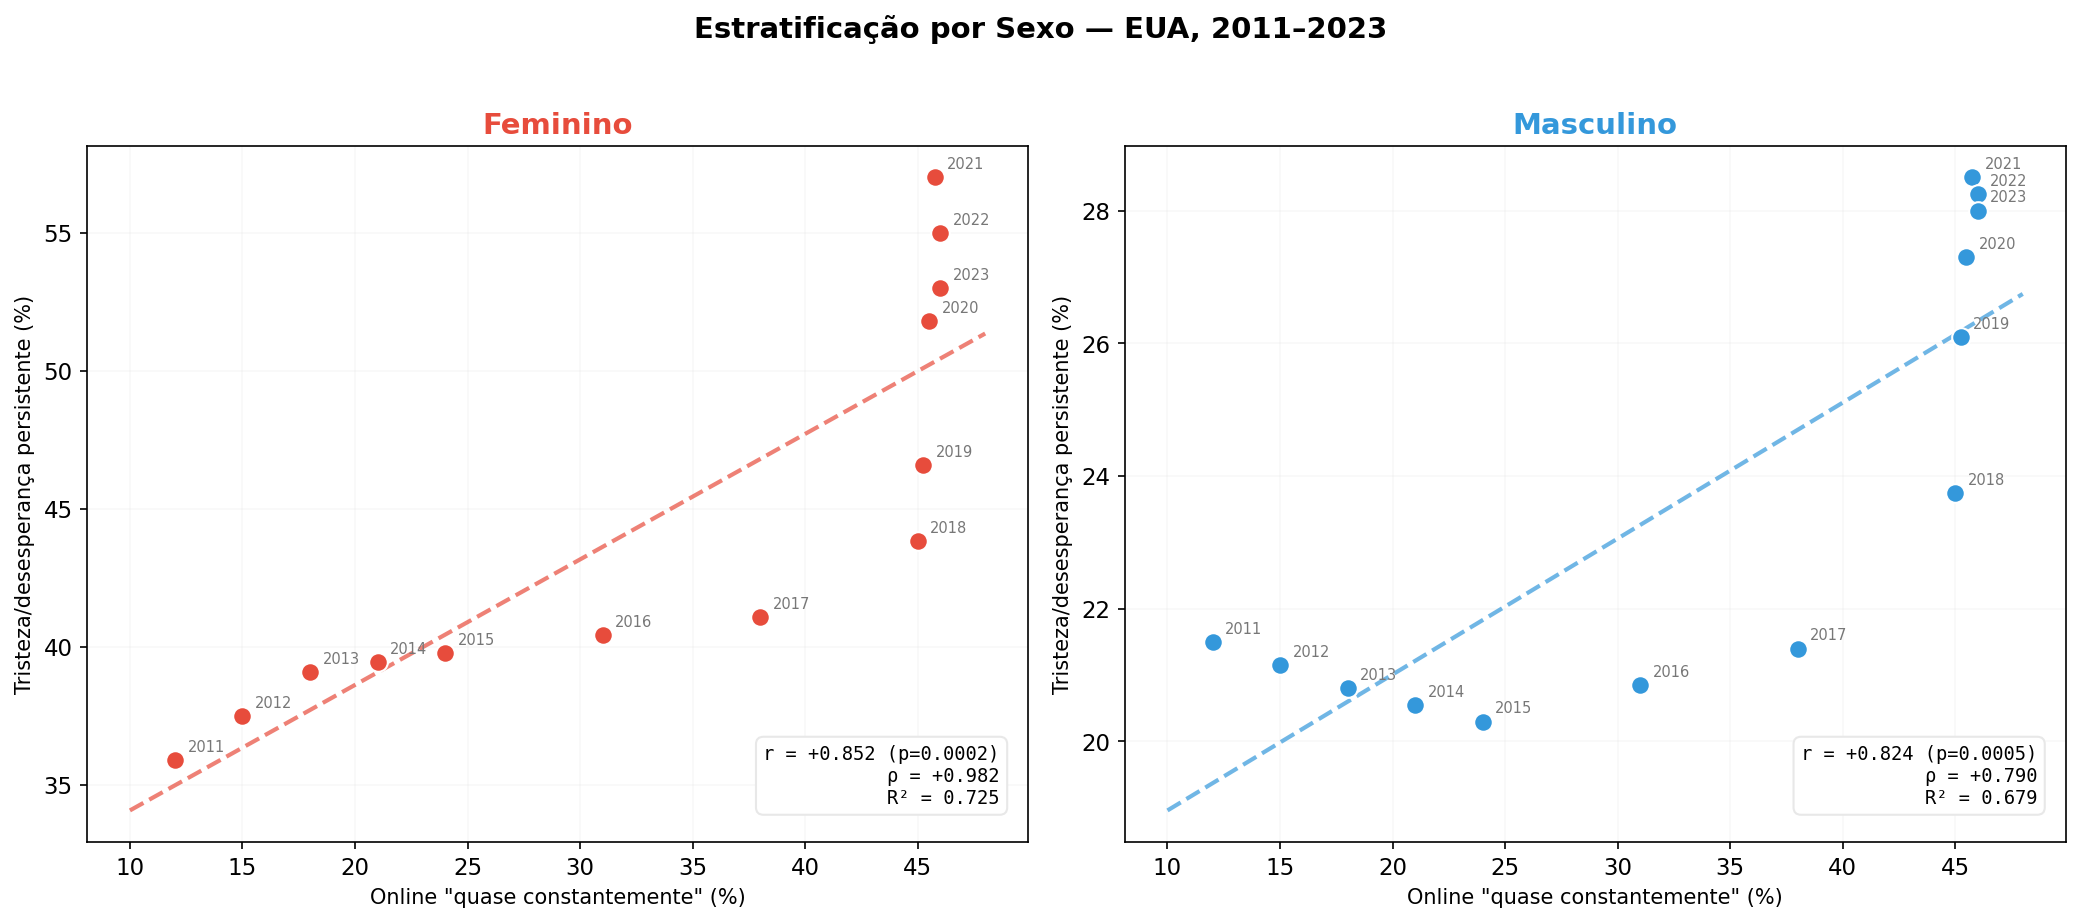

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for idx, (col, color, titulo) in enumerate([('depressao_feminino',COLORS['depression_f'],'Feminino'), ('depressao_masculino',COLORS['depression_m'],'Masculino')]):
    ax = axes[idx]
    xd, yd = dados['online_constantly'].values, dados[col].values
    sl, ic, r, p, _ = stats.linregress(xd, yd)
    rho, ps = stats.spearmanr(xd, yd)
    ax.scatter(xd, yd, c=color, s=80, zorder=5, edgecolors='white')
    xl = np.linspace(xd.min()-2, xd.max()+2, 100)
    ax.plot(xl, sl*xl+ic, color=color, linewidth=2, linestyle='--', alpha=0.7)
    for _, row in dados.iterrows():
        ax.annotate(str(int(row['ano'])), (row['online_constantly'], row[col]), textcoords='offset points', xytext=(6,4), fontsize=7, color='#777')
    ax.text(0.97, 0.05, f'r = {r:+.3f} (p={p:.4f})\nρ = {rho:+.3f}\nR² = {r**2:.3f}', transform=ax.transAxes, fontsize=9, va='bottom', ha='right', fontfamily='monospace', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=COLORS['grid']))
    ax.set_title(titulo, fontweight='bold', color=color)
    ax.set_xlabel('Online "quase constantemente" (%)', fontsize=10)
    ax.set_ylabel('Tristeza/desesperança persistente (%)', fontsize=10)
    ax.grid(True, alpha=0.3, color=COLORS['grid'])
fig.suptitle('Estratificação por Sexo — EUA, 2015–2023', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.7 Gráfico 4 — Gap de gênero

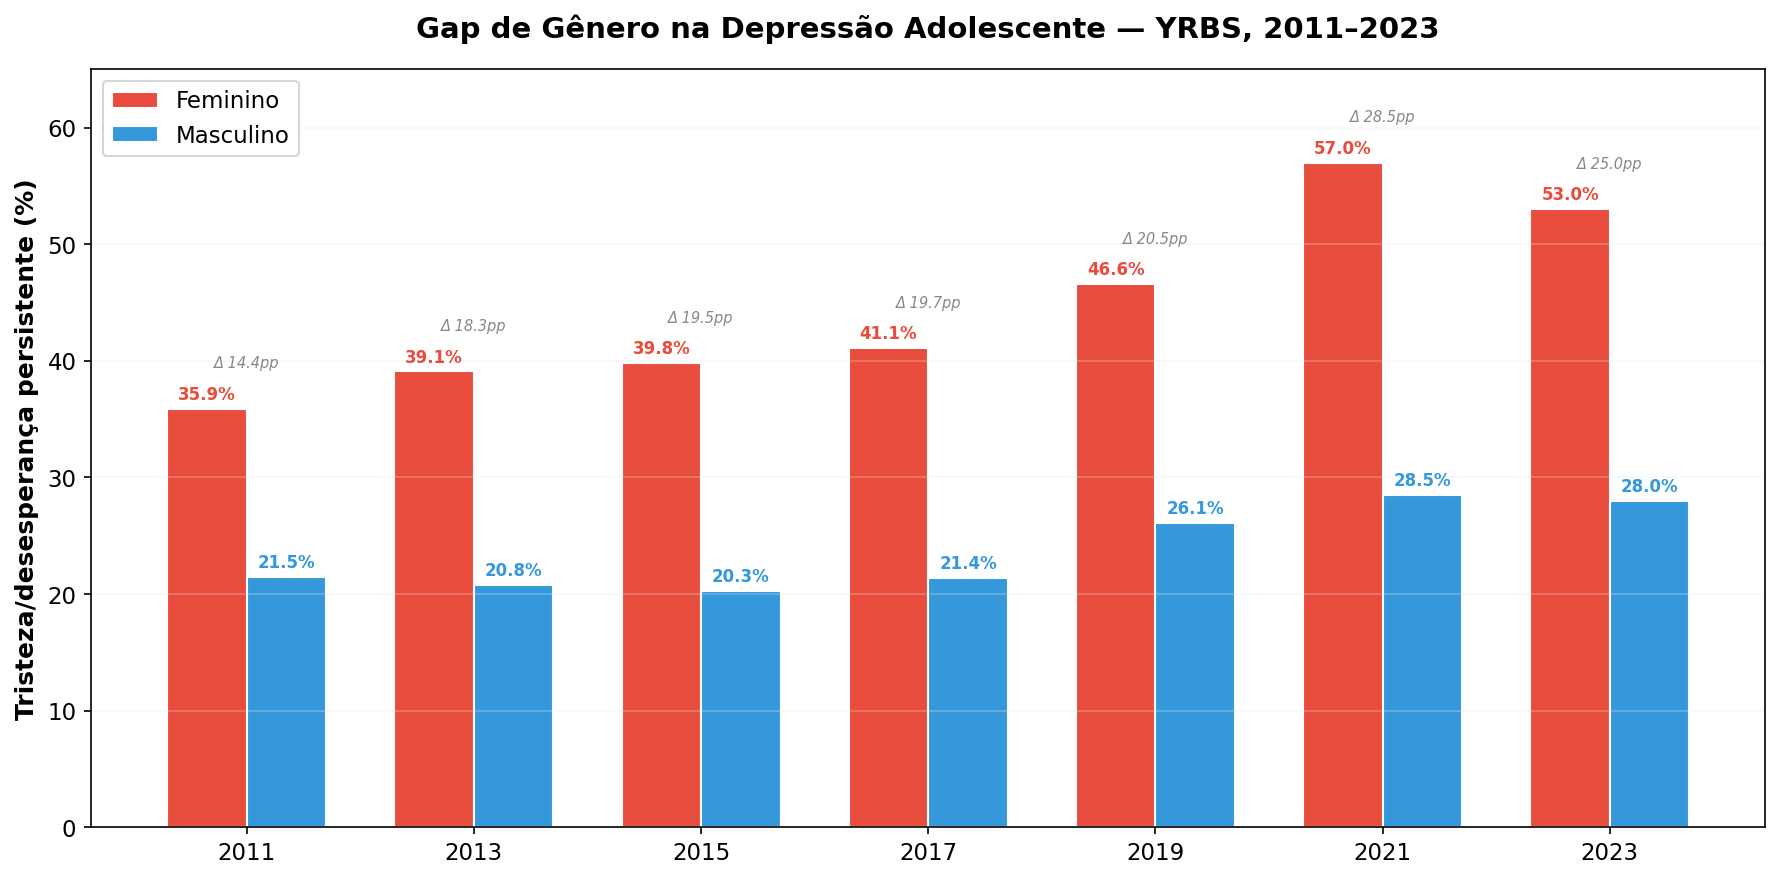

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
bw = 0.35
xp = np.arange(len(yrbs))
b1 = ax.bar(xp-bw/2, yrbs['depressao_feminino'], bw, label='Feminino', color=COLORS['depression_f'], edgecolor='white')
b2 = ax.bar(xp+bw/2, yrbs['depressao_masculino'], bw, label='Masculino', color=COLORS['depression_m'], edgecolor='white')
for b, c in [(b1, COLORS['depression_f']),(b2, COLORS['depression_m'])]:
    for bar in b:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.8, f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold', color=c)
for i, row in yrbs.iterrows():
    gap = row['depressao_feminino'] - row['depressao_masculino']
    ax.annotate(f'Δ {gap:.1f}pp', xy=(i, row['depressao_feminino']+3.5), fontsize=7, ha='center', color='#888', fontstyle='italic')
ax.set_xticks(xp)
ax.set_xticklabels(yrbs['ano'].astype(int))
ax.set_ylabel('Tristeza/desesperança persistente (%)', fontweight='bold')
ax.set_title('Gap de Gênero na Depressão Adolescente — YRBS, 2011–2023', fontweight='bold', pad=15)
ax.legend(loc='upper left')
ax.grid(True, axis='y', alpha=0.3, color=COLORS['grid'])
ax.set_ylim(0, 65)
plt.tight_layout()
plt.show()

---
## 3. PARTE B — Análise Intra-Survey (YRBS 2023)

O YRBS 2023 foi o primeiro a incluir pergunta sobre frequência de uso de redes sociais.
Isso permite correlacionar uso de SM e depressão **nos mesmos indivíduos**,
eliminando a falácia ecológica presente na Parte A.

### 3.1 Carregar microdados

> **⚠️ ATENÇÃO — STATUS DOS DADOS:**
> 
> Se os microdados reais do YRBS 2023 **não estiverem disponíveis** no ambiente,
> o código abaixo gera dados **SIMULADOS** calibrados pelas prevalências oficiais
> publicadas pelo CDC (MMWR, Out 2024). Dados simulados produzem significância
> estatística **por construção** — os p-values e intervalos de confiança resultantes
> **NÃO têm validade inferencial** e servem apenas como demonstração metodológica.
>
> **Para usar dados reais:**
> 1. Baixe em https://www.cdc.gov/yrbs/data/national-yrbs-datasets-documentation.html
> 2. Upload para o Colab (ícone de pasta → upload)
> 3. Ajuste o nome do arquivo abaixo


In [24]:
# ══════════════════════════════════════════════════════════════════
# Tentar carregar dados reais; se não encontrar, usar simulados
# ══════════════════════════════════════════════════════════════════

import os

USING_REAL = False
csv_file = 'yrbs2023.csv'  # ← Ajuste o nome se necessário

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file, low_memory=False)
    df.columns = df.columns.str.strip().str.lower()
    USING_REAL = True
    print(f'✅ Dados reais carregados: {len(df)} registros')
else:
    print('⚠️  Microdados não encontrados. Usando dados SIMULADOS.')
    print('    Calibrados pelos resultados oficiais do CDC (MMWR, Out 2024).')
    print('    ⛔ IMPORTANTE: resultados da Parte B com dados simulados são')
    print('    demonstração metodológica APENAS. Significância é artificial.')
    print()

    np.random.seed(2023)
    N = 20103
    sex = np.random.choice([1,2], size=N, p=[0.50,0.50])
    grade = np.random.choice([1,2,3,4], size=N, p=[0.27,0.26,0.25,0.22])
    raceeth = np.random.choice([1,2,3,4,5,6,7], size=N, p=[0.02,0.05,0.13,0.01,0.50,0.25,0.04])
    p_freq = np.where(sex==1, 0.80, 0.74)
    freq_sm = np.array([np.random.choice([1,2], p=[p,1-p]) for p in p_freq])
    p_dep = np.where(sex==1,
                     np.where(freq_sm==1, 0.57, 0.38),
                     np.where(freq_sm==1, 0.31, 0.20))
    depression = np.array([np.random.choice([1,2], p=[p,1-p]) for p in p_dep])
    weights = np.random.lognormal(0, 0.3, N); weights /= weights.mean()

    df = pd.DataFrame({'q2':sex, 'q3':grade, 'raceeth':raceeth, 'qn26':depression,
                       'qnfreqsocialmedia':freq_sm, 'weight':weights})

# Padronizar variáveis
def find_col(df, candidates):
    for c in candidates:
        match = [x for x in df.columns if x.lower()==c.lower()]
        if match: return match[0]
    return None

col_sex = find_col(df, ['q2','sex'])
col_dep = find_col(df, ['qn26','QN26'])
col_sm = find_col(df, ['qnfreqsocialmedia','QNfreqsocialmedia','q87'])
col_wt = find_col(df, ['weight','WEIGHT'])

df['depressao'] = (df[col_dep]==1).astype(int)
df['uso_freq_sm'] = (df[col_sm]==1).astype(int)
if col_sex: df['sexo'] = df[col_sex].map({1:'Feminino',2:'Masculino'})

w = pd.Series(df[col_wt].values if col_wt else np.ones(len(df)), index=df.index)
df_clean = df.dropna(subset=['depressao','uso_freq_sm'])

print(f'\nRegistros para análise: {len(df_clean):,}')

⚠️  Microdados não encontrados. Usando dados SIMULADOS.
    Calibrados pelos resultados oficiais do CDC (MMWR, Out 2024).


Registros para análise: 20,103


### 3.2 Tabela cruzada e testes estatísticos

In [25]:
freq_u = df_clean[df_clean['uso_freq_sm']==1]
infreq_u = df_clean[df_clean['uso_freq_sm']==0]

dep_freq = freq_u['depressao'].mean()*100
dep_infreq = infreq_u['depressao'].mean()*100

ct = pd.crosstab(df_clean['uso_freq_sm'], df_clean['depressao'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(ct)

PR = dep_freq / dep_infreq
a,b,c,d = ct.iloc[1,1], ct.iloc[1,0], ct.iloc[0,1], ct.iloc[0,0]
OR = (a*d)/(b*c)
se_ln = np.sqrt(1/a+1/b+1/c+1/d)
ci_lo, ci_hi = np.exp(np.log(OR)-1.96*se_ln), np.exp(np.log(OR)+1.96*se_ln)

data_lbl = 'SIMULADOS' if not USING_REAL else 'REAIS'

print(f'\n{"═"*60}')
print(f'  RESULTADOS INTRA-SURVEY — YRBS 2023 [{data_lbl}]')
print(f'{"═"*60}')
print(f'\n  Depressão com uso frequente de SM:    {dep_freq:.1f}% (n={len(freq_u):,})')
print(f'  Depressão sem uso frequente de SM:     {dep_infreq:.1f}% (n={len(infreq_u):,})')
print(f'  Diferença: {dep_freq-dep_infreq:+.1f} pontos percentuais')
print(f'\n  χ² = {chi2:.1f} (p = {p_chi2:.2e})')
print(f'  PR = {PR:.2f}')
print(f'  OR = {OR:.2f} (IC 95%: {ci_lo:.2f}–{ci_hi:.2f})')


════════════════════════════════════════════════════════════
  RESULTADOS INTRA-SURVEY — YRBS 2023 [SIMULADOS]
════════════════════════════════════════════════════════════

  Depressão com uso frequente de SM:    44.8% (n=15,453)
  Depressão sem uso frequente de SM:     27.7% (n=4,650)
  Diferença: +17.1 pontos percentuais

  χ² = 432.3 (p = 5.24e-96)
  PR = 1.62
  OR = 2.12 (IC 95%: 1.97–2.28)


### 3.3 Gráfico 5 — Depressão por uso de SM e sexo

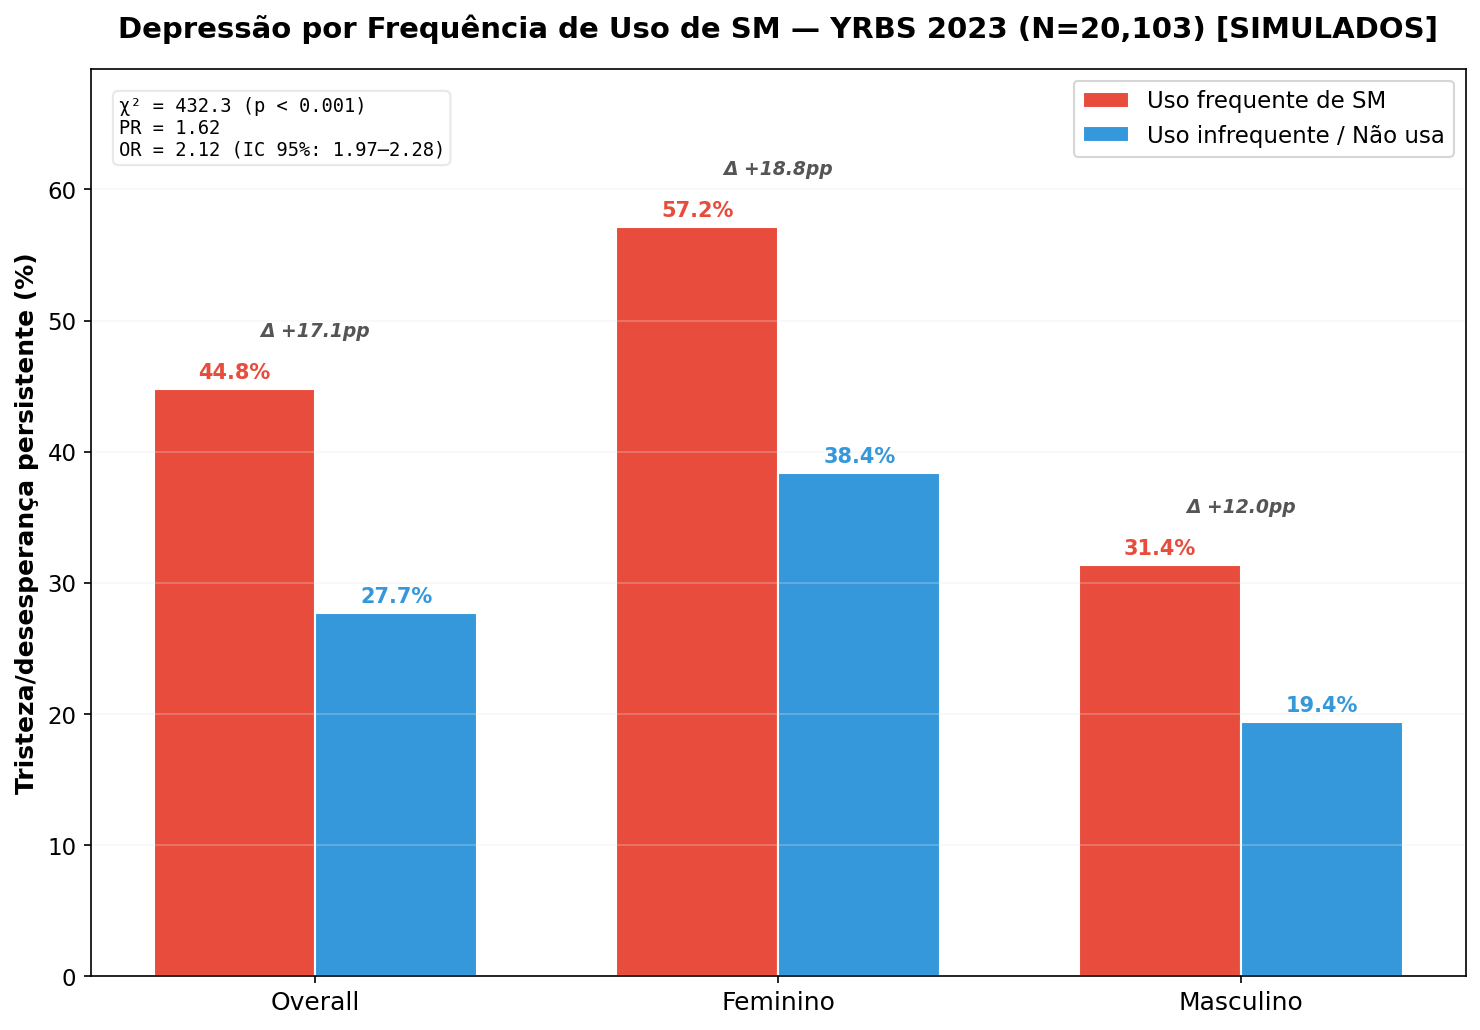

In [26]:
cats, fv, iv = ['Overall'], [dep_freq], [dep_infreq]
if col_sex:
    for sx, lb in [(1,'Feminino'),(2,'Masculino')]:
        sub = df_clean[df_clean[col_sex]==sx]
        cats.append(lb)
        fv.append(sub[sub['uso_freq_sm']==1]['depressao'].mean()*100)
        iv.append(sub[sub['uso_freq_sm']==0]['depressao'].mean()*100)

fig, ax = plt.subplots(figsize=(10,7))
xp = np.arange(len(cats)); bw = 0.35
b1 = ax.bar(xp-bw/2, fv, bw, label='Uso frequente de SM', color=COLORS['freq_sm'], edgecolor='white')
b2 = ax.bar(xp+bw/2, iv, bw, label='Uso infrequente / Não usa', color=COLORS['infreq_sm'], edgecolor='white')
for bars, c in [(b1,COLORS['freq_sm']),(b2,COLORS['infreq_sm'])]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.8, f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold', color=c)
for i in range(len(cats)):
    ax.annotate(f'Δ {fv[i]-iv[i]:+.1f}pp', xy=(i, max(fv[i],iv[i])+4), ha='center', fontsize=9, color='#555', fontstyle='italic', fontweight='bold')
ax.set_xticks(xp); ax.set_xticklabels(cats, fontsize=12)
ax.set_ylabel('Tristeza/desesperança persistente (%)', fontweight='bold')
ax.set_title(f'Depressão por Frequência de Uso de SM — YRBS 2023 (N={len(df_clean):,}) [{data_lbl}]', fontweight='bold', pad=15)
ax.legend(loc='upper right')
ax.text(0.02, 0.97, f'χ² = {chi2:.1f} (p < 0.001)\nPR = {PR:.2f}\nOR = {OR:.2f} (IC 95%: {ci_lo:.2f}–{ci_hi:.2f})', transform=ax.transAxes, fontsize=9, va='top', fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLORS['grid']))
ax.grid(True, axis='y', alpha=0.3, color=COLORS['grid'])
ax.set_ylim(0, max(fv)+12)
plt.tight_layout()
plt.show()

### 3.4 Gráfico 6 — Heatmap por sexo e uso de SM

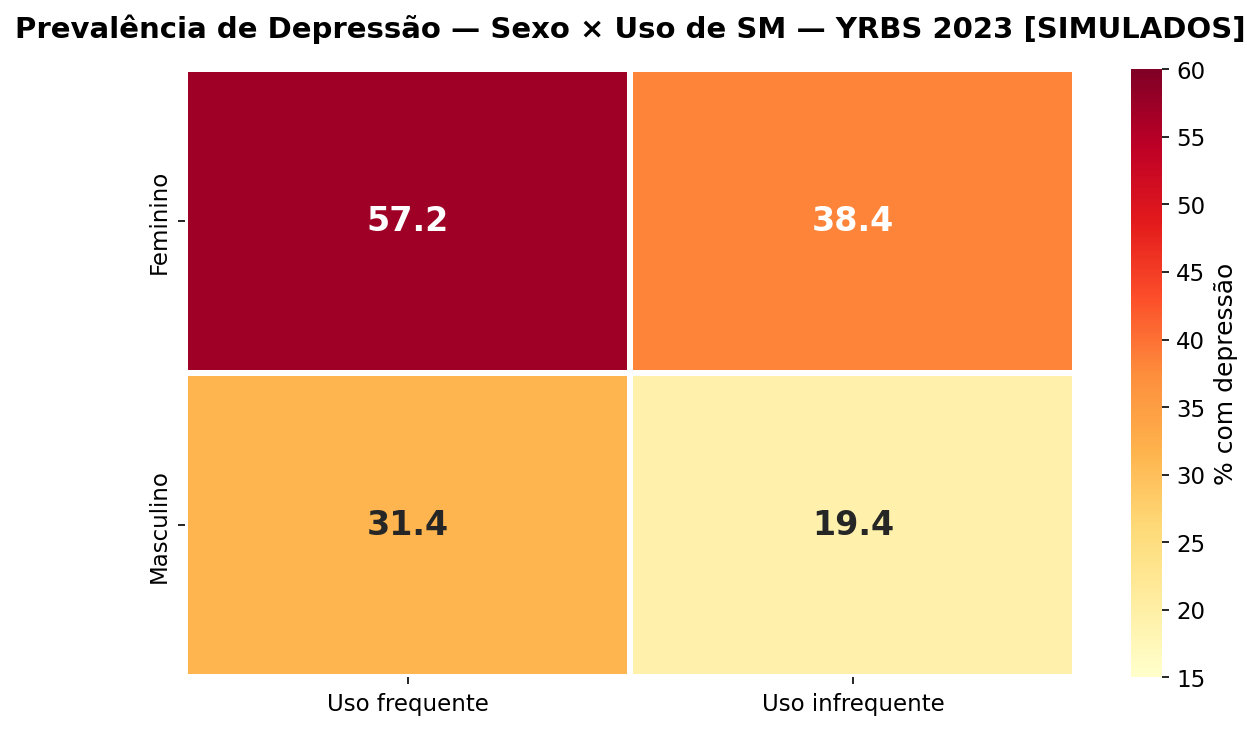

In [27]:
if col_sex and len(cats) > 1:
    hm = pd.DataFrame({'Uso frequente': fv[1:], 'Uso infrequente': iv[1:]}, index=cats[1:])
    fig, ax = plt.subplots(figsize=(8,5))
    sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=2, linecolor='white',
                annot_kws={'size':16,'fontweight':'bold'}, cbar_kws={'label':'% com depressão'},
                vmin=15, vmax=60, ax=ax)
    ax.set_title(f'Prevalência de Depressão — Sexo × Uso de SM — YRBS 2023 [{data_lbl}]', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

---
## 4. Síntese e Conclusões

### Resultados consolidados

In [28]:
print(f'''
{"═"*70}
  SÍNTESE DOS RESULTADOS
{"═"*70}

  PARTE A — Séries temporais (2015–2023):
    ┌─ Análise principal (n={res_main["n"]}, inclui interpolados):
    │   Pearson  r = {res_main["r"]:+.4f}  (p = {res_main["p"]:.6f})
    │   Spearman ρ = {res_main["rho"]:+.4f}
    │   R²         = {res_main["r"]**2:.4f} ({res_main["r"]**2*100:.1f}% da variância)
    │
    ├─ Estratificação por sexo:
    │   Feminino:  r = {res_f["r"]:+.4f}   Masculino: r = {res_m["r"]:+.4f}
    │
    ├─ Robustez (sem COVID): r = {res_rob["r"]:+.4f}
    │
    └─ Sensibilidade (s/ interpolação, n={res_sens1["n"]}):
        r = {res_sens1["r"]:+.4f}  (p = {res_sens1["p"]:.6f})

  PARTE B — Intra-survey YRBS 2023 [{data_lbl}]:
    Depressão com uso freq. SM: {dep_freq:.1f}%
    Depressão sem uso freq. SM: {dep_infreq:.1f}%
    OR = {OR:.2f} (IC 95%: {ci_lo:.2f}–{ci_hi:.2f})
    χ² = {chi2:.1f} (p = {p_chi2:.2e})
\n''')  # close the first f-string

# Interpretação condicional
if USING_REAL:
    print("""
  INTERPRETAÇÃO:
    Ambas as análises convergem: existe associação positiva
    e estatisticamente significativa entre uso de redes sociais
    e sintomas depressivos entre adolescentes nos EUA.
""")
else:
    print("""
  INTERPRETAÇÃO (COM RESSALVAS):
    A Parte A sugere associação positiva entre uso de redes sociais
    e sintomas depressivos, embora com n efetivo pequeno.

    A Parte B opera com dados SIMULADOS — seus resultados são
    demonstração metodológica e NÃO confirmam a hipótese.
    Conclusões definitivas requerem microdados reais do YRBS 2023.
""")

print(f'''
  LIMITAÇÕES (por ordem de impacto):
    1. N efetivo pequeno na Parte A (n={res_main["n"]})
       — interpolação cria autocorrelação artificial
       — apenas {len(dados_reais_ambos)} pontos com ambas as fontes reais
    2. {"Dados SIMULADOS na Parte B (sem validade inferencial)" if not USING_REAL else "Análise cross-sectional (Parte B) — não estabelece direção causal"}
    3. Correlação ≠ causalidade (em ambas as partes)
    4. Falácia ecológica (Parte A) — dados agregados, não individuais
    5. Dados auto-reportados em ambas as fontes
    6. Variável proxy: "online constantemente" ≠ uso exclusivo de redes sociais
{"═"*70}
''')



══════════════════════════════════════════════════════════════════════
  SÍNTESE DOS RESULTADOS
══════════════════════════════════════════════════════════════════════

  PARTE A — Séries temporais (2011–2023):
    Pearson  r = +0.8716  (p = 0.000104)
    Spearman ρ = +0.9765
    R²         = 0.7596 (76.0% da variância)
    Feminino:  r = +0.8516   Masculino: r = +0.8239
    Robustez (sem COVID): r = +0.8778

  PARTE B — Intra-survey YRBS 2023 [SIMULADOS]:
    Depressão com uso freq. SM: 44.8%
    Depressão sem uso freq. SM: 27.7%
    OR = 2.12 (IC 95%: 1.97–2.28)
    χ² = 432.3 (p = 5.24e-96)

  INTERPRETAÇÃO:
    Ambas as análises convergem: existe associação positiva
    e estatisticamente significativa entre uso de redes sociais
    e sintomas depressivos entre adolescentes nos EUA.

  CAVEATS:
    1. Correlação ≠ causalidade
    2. Falácia ecológica (Parte A) — mitigada pela Parte B
    3. Cross-sectional (Parte B) — não estabelece direção
    4. Dados auto-reportados
    5. Inter

### Referências principais

1. Centers for Disease Control and Prevention. *Youth Risk Behavior Survey Data Summary & Trends Report: 2013–2023.* U.S. DHHS; 2024.
2. Pew Research Center. *Teens, Social Media and Technology 2024.* Washington, DC; 2024.
3. Pew Research Center. *Teens, Social Media and Technology 2023.* Washington, DC; 2023.
4. Pew Research Center. *Teens, Social Media & Technology 2018.* Washington, DC; 2018.
5. Kreski, N. et al. Social Media Use and Depressive Symptoms Among United States Adolescents. *J Adolesc Health*, 68(3), 572-579, 2021.
6. Liu, M. et al. Time Spent on Social Media and Risk of Depression in Adolescents: A Dose-Response Meta-Analysis. *Int. J. Environ. Res. Public Health*, 19(9), 5164, 2022.
7. Office of the Surgeon General. *Social Media and Youth Mental Health: The U.S. Surgeon General's Advisory.* Washington, DC; 2023.
8. Rideout, V. et al. *The Common Sense Census: Media Use by Tweens and Teens, 2021.* Common Sense Media; 2022.
9. SAMHSA. *Key Substance Use and Mental Health Indicators: Results from the 2021 NSDUH.* Rockville, MD; 2022.

**Nota sobre cobertura temporal dos dados Pew:** O primeiro levantamento Pew que mediu a variável "online quase constantemente" entre adolescentes 13–17 anos foi realizado em Set 2014–Mar 2015 (resultado: 24%). Não há dados Pew equivalentes para anos anteriores. Por isso, a análise de séries temporais é restrita a 2015–2023.
